<a href="https://colab.research.google.com/github/Nguza/AI-Project-Portfolio-/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.decomposition import PCA


Dataset

In [ ]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [ ]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

Pre-Processing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.drop_duplicates().sum()

,0
sepal length (cm),870.7
sepal width (cm),455.9
petal length (cm),558.6
petal width (cm),178.0
target,148.0


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.993289
std,0.830851,0.436342,1.767791,0.762622,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Preparing data for Modeling

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Supervised Learning Model (Logistic Regression)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
X_test

array([[ 0.30961079, -0.59725494,  0.53977784,  0.0070641 ],
       [-0.17344688,  1.70225374, -1.16297935, -1.17705491],
       [ 2.2418415 ,  1.70225374,  1.6749493 ,  1.32275187],
       [ 0.18884637, -0.36730407,  0.42626069,  0.40177043],
       [ 1.15496173, -0.59725494,  0.59653641,  0.27020165],
       [-0.53574014,  0.78245027, -1.2764965 , -1.04548613],
       [-0.2942113 , -0.36730407, -0.08456646,  0.13863287],
       [ 1.03419731,  0.09259766,  1.05060499,  1.58588943],
       [ 0.43037521, -1.97696014,  0.42626069,  0.40177043],
       [-0.05268246, -0.8272058 ,  0.08570925,  0.0070641 ],
       [ 1.63801941,  1.242352  ,  1.33439786,  1.71745821],
       [-1.26032666, -0.1373532 , -1.33325507, -1.44019246],
       [-0.41497572,  1.01240113, -1.39001364, -1.30862368],
       [-1.13956224,  0.09259766, -1.2764965 , -1.44019246],
       [-0.8980334 ,  1.70225374, -1.2764965 , -1.17705491],
       [ 0.55113963,  0.5524994 ,  0.53977784,  0.53333921],
       [ 0.55113963,  0.

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

Evaluated Supervised Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


Unsupervised Learning Model (K-Means Clustering)

In [ ]:
Kmeans = KMeans(n_clusters=3, random_state=42)
clusters = Kmeans.fit_predict(X)

df['cluster'] = clusters
df.head(40)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
5,5.4,3.9,1.7,0.4,0,1
6,4.6,3.4,1.4,0.3,0,1
7,5.0,3.4,1.5,0.2,0,1
8,4.4,2.9,1.4,0.2,0,1
9,4.9,3.1,1.5,0.1,0,1


In [ ]:
df.tail(30)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
119,6.0,2.2,5.0,1.5,2,2
120,6.9,3.2,5.7,2.3,2,0
121,5.6,2.8,4.9,2.0,2,2
122,7.7,2.8,6.7,2.0,2,0
123,6.3,2.7,4.9,1.8,2,2
124,6.7,3.3,5.7,2.1,2,0
125,7.2,3.2,6.0,1.8,2,0
126,6.2,2.8,4.8,1.8,2,2
127,6.1,3.0,4.9,1.8,2,2
128,6.4,2.8,5.6,2.1,2,0


Visualize Clustering (PCA)

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PAC1'] = X_pca[:, 0]
df['PAC2'] = X_pca[:, 1]



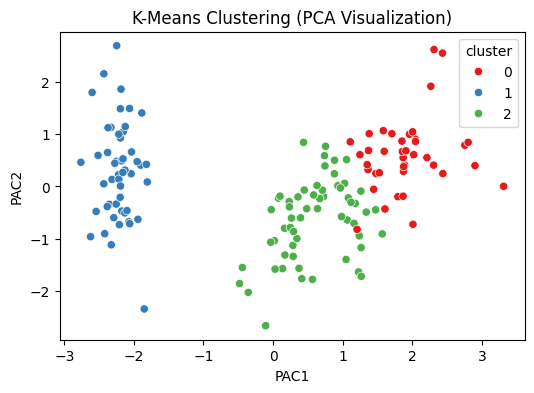

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='PAC1', y='PAC2', hue='cluster', palette='Set1')
plt.title("K-Means Clustering (PCA Visualization)")
plt.show()

(1)
The goal of a machine learningis to find the "sweet spot"—the optimal balance where the model is complex enough to capture the true patterns in the data, but simple enough to generalize well to new, unseen information. This balancing act is the core of creating robust AI systems that don't just memorize data, but actually "learn" from it.
(2)
The Bias-Variance tradeoff represents the fundamental tension between a model's ability to minimize systematic error through complexity and its susceptibility to performance instability caused by noise in the training data. A model with high bias risks oversimplifying reality and failing to capture essential patterns, while a model with high variance risks overfitting by treating random, irrelevant fluctuations as meaningful insights.